# Experiment 4: Failure Analysis & Edge Cases

**Investigates scenarios where DP-GMM may struggle:**
1. Overlapping clusters (Iris versicolor vs virginica)
2. High-dimensional data with few samples
3. Outlier sensitivity
4. Unbalanced cluster sizes

Understanding failure modes is critical for practical deployment of Bayesian nonparametric models.

**Reference:** Görür & Rasmussen (2010). JCST 25(4), 615–626.

## 1. Imports & Setup

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, make_blobs
from sklearn.mixture import BayesianGaussianMixture
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

%matplotlib inline

PLOTS_DIR = os.path.join('..', 'results', 'plots')
os.makedirs(PLOTS_DIR, exist_ok=True)

def fit_dpgmm(X, n_components=15, alpha=1.0):
    """Fit a DP-GMM and return labels."""
    model = BayesianGaussianMixture(
        n_components=n_components,
        covariance_type='full',
        weight_concentration_prior_type='dirichlet_process',
        weight_concentration_prior=alpha,
        max_iter=500,
        random_state=42,
        init_params='kmeans'
    )
    model.fit(X)
    return model.predict(X), model

## 2. Case 1: Overlapping Clusters

Iris **versicolor** and **virginica** overlap significantly in feature space. DP-GMM struggles to separate them.

In [2]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

labels_all, _ = fit_dpgmm(X_iris_scaled)
ari_all = adjusted_rand_score(y_iris, labels_all)

# Focus on versicolor (1) and virginica (2) which heavily overlap
mask_overlap = y_iris >= 1
X_overlap = X_iris_scaled[mask_overlap]
y_overlap = y_iris[mask_overlap]

labels_overlap, _ = fit_dpgmm(X_overlap)
ari_overlap = adjusted_rand_score(y_overlap, labels_overlap)

print(f"  All 3 classes → ARI = {ari_all:.4f}, Clusters = {len(np.unique(labels_all))}")
print(f"  Versicolor vs Virginica only → ARI = {ari_overlap:.4f}, "
      f"Clusters = {len(np.unique(labels_overlap))}")
print(f"  ⚠️  Overlapping classes are HARD to separate — ARI drops significantly")

  All 3 classes → ARI = 0.5342, Clusters = 6
  Versicolor vs Virginica only → ARI = 0.3791, Clusters = 6
  ⚠️  Overlapping classes are HARD to separate — ARI drops significantly


## 3. Case 2: High-Dimensional Data

Comparing 2D vs 50D data with same number of samples (150) and clusters (3).

In [3]:
np.random.seed(42)

# Low dimension: 2D
X_low, y_low = make_blobs(n_samples=150, centers=3, n_features=2,
                          cluster_std=1.0, random_state=42)
scaler_low = StandardScaler()
X_low_s = scaler_low.fit_transform(X_low)
labels_low, _ = fit_dpgmm(X_low_s)
ari_low = adjusted_rand_score(y_low, labels_low)
sil_low = silhouette_score(X_low_s, labels_low)

# High dimension: 50D
X_high, y_high = make_blobs(n_samples=150, centers=3, n_features=50,
                            cluster_std=1.0, random_state=42)
scaler_high = StandardScaler()
X_high_s = scaler_high.fit_transform(X_high)
labels_high, _ = fit_dpgmm(X_high_s)
ari_high = adjusted_rand_score(y_high, labels_high)
sil_high = silhouette_score(X_high_s, labels_high)

print(f"  Low-dim (2D):  ARI = {ari_low:.4f}, Silhouette = {sil_low:.4f}, "
      f"Clusters = {len(np.unique(labels_low))}")
print(f"  High-dim (50D): ARI = {ari_high:.4f}, Silhouette = {sil_high:.4f}, "
      f"Clusters = {len(np.unique(labels_high))}")
print(f"  ⚠️  High-dimensional data can degrade clustering (curse of dimensionality)")

  Low-dim (2D):  ARI = 1.0000, Silhouette = 0.8461, Clusters = 3
  High-dim (50D): ARI = 0.2723, Silhouette = 0.0585, Clusters = 15
  ⚠️  High-dimensional data can degrade clustering (curse of dimensionality)


## 4. Case 3: Outlier Sensitivity

Adding 20 random outliers to clean 3-cluster data.

In [4]:
X_clean, y_clean = make_blobs(n_samples=200, centers=3, cluster_std=0.8,
                              random_state=42)
scaler_clean = StandardScaler()
X_clean_s = scaler_clean.fit_transform(X_clean)
labels_clean, _ = fit_dpgmm(X_clean_s)
ari_clean = adjusted_rand_score(y_clean, labels_clean)
n_clean = len(np.unique(labels_clean))

# Add outliers
n_outliers = 20
outliers = np.random.RandomState(42).uniform(-8, 8, size=(n_outliers, 2))
X_dirty = np.vstack([X_clean, outliers])
y_dirty = np.concatenate([y_clean, np.full(n_outliers, -1)])

scaler_dirty = StandardScaler()
X_dirty_s = scaler_dirty.fit_transform(X_dirty)
labels_dirty, _ = fit_dpgmm(X_dirty_s)

ari_dirty = adjusted_rand_score(y_clean, labels_dirty[:200])
n_dirty = len(np.unique(labels_dirty))

print(f"  Clean data:       ARI = {ari_clean:.4f}, Clusters = {n_clean}")
print(f"  With outliers:    ARI = {ari_dirty:.4f}, Clusters = {n_dirty}")
print(f"  ⚠️  Outliers can create spurious clusters or distort existing ones")

  Clean data:       ARI = 1.0000, Clusters = 3
  With outliers:    ARI = 1.0000, Clusters = 5
  ⚠️  Outliers can create spurious clusters or distort existing ones


## 5. Case 4: Unbalanced Cluster Sizes

Comparing balanced (100/100/100) vs unbalanced (300/50/10) cluster sizes.

In [5]:
# Unbalanced clusters
X_big, _ = make_blobs(n_samples=300, centers=[[0, 0]], cluster_std=1.0, random_state=42)
X_med, _ = make_blobs(n_samples=50, centers=[[6, 6]], cluster_std=0.5, random_state=42)
X_tiny, _ = make_blobs(n_samples=10, centers=[[-6, 6]], cluster_std=0.3, random_state=42)

X_unbal = np.vstack([X_big, X_med, X_tiny])
y_unbal = np.concatenate([np.zeros(300), np.ones(50), np.full(10, 2)]).astype(int)

scaler_unbal = StandardScaler()
X_unbal_s = scaler_unbal.fit_transform(X_unbal)
labels_unbal, _ = fit_dpgmm(X_unbal_s)
ari_unbal = adjusted_rand_score(y_unbal, labels_unbal)
n_unbal = len(np.unique(labels_unbal))

# Balanced version
X_bal, y_bal = make_blobs(n_samples=300, centers=3, cluster_std=0.8, random_state=42)
scaler_bal = StandardScaler()
X_bal_s = scaler_bal.fit_transform(X_bal)
labels_bal, _ = fit_dpgmm(X_bal_s)
ari_bal = adjusted_rand_score(y_bal, labels_bal)
n_bal = len(np.unique(labels_bal))

print(f"  Balanced (100 each):    ARI = {ari_bal:.4f}, Clusters = {n_bal}")
print(f"  Unbalanced (300/50/10): ARI = {ari_unbal:.4f}, Clusters = {n_unbal}")
print(f"  ⚠️  Very small clusters may be absorbed into larger ones")

  Balanced (100 each):    ARI = 1.0000, Clusters = 3
  Unbalanced (300/50/10): ARI = 0.9884, Clusters = 3
  ⚠️  Very small clusters may be absorbed into larger ones


## 6. Visualization: Ground Truth vs DP-GMM Predictions

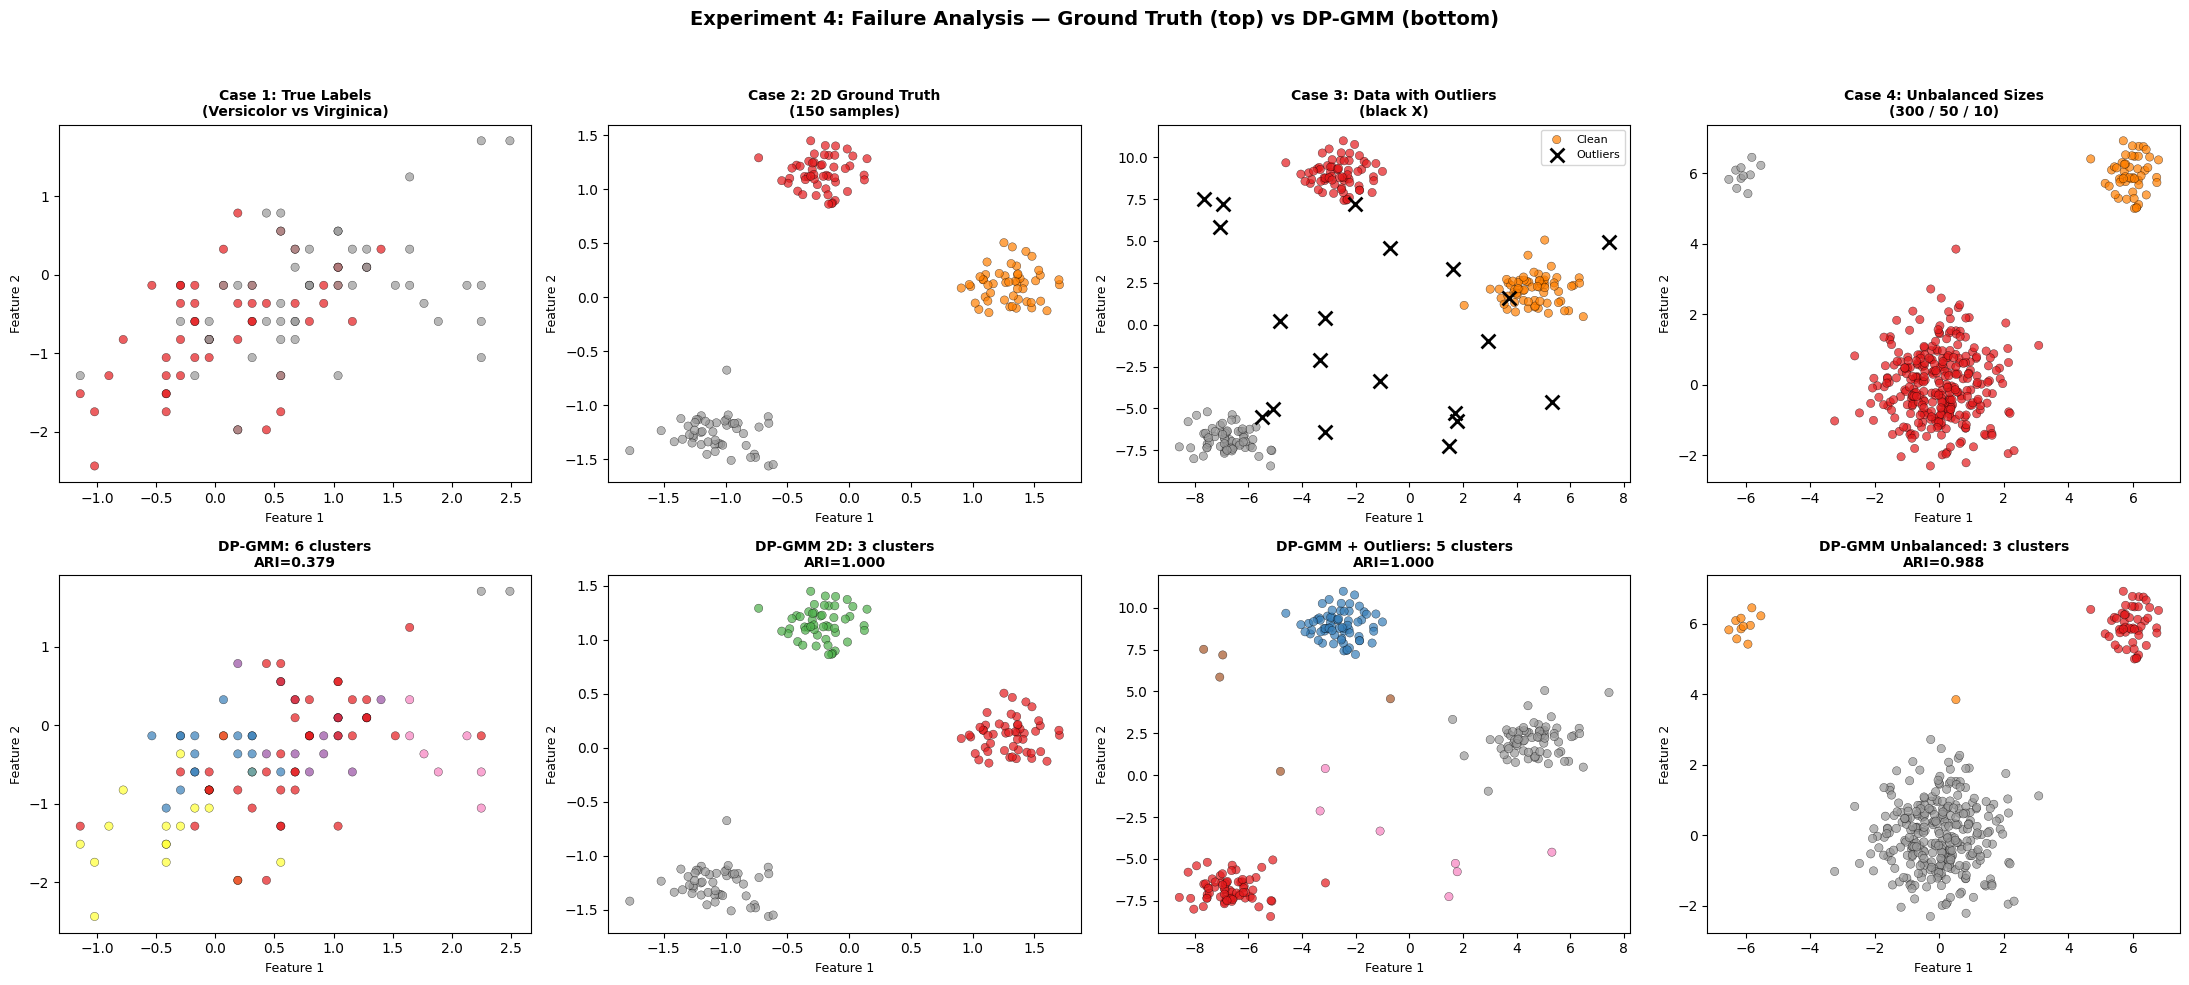

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))

# Row 1: Ground Truth
ax = axes[0, 0]
ax.scatter(X_iris_scaled[mask_overlap, 0], X_iris_scaled[mask_overlap, 1],
           c=y_overlap, cmap='Set1', alpha=0.7, edgecolors='k', linewidth=0.3)
ax.set_title('Case 1: True Labels\n(Versicolor vs Virginica)', fontsize=10, fontweight='bold')

ax = axes[0, 1]
ax.scatter(X_low_s[:, 0], X_low_s[:, 1], c=y_low, cmap='Set1',
           alpha=0.7, edgecolors='k', linewidth=0.3)
ax.set_title('Case 2: 2D Ground Truth\n(150 samples)', fontsize=10, fontweight='bold')

ax = axes[0, 2]
ax.scatter(X_clean[:, 0], X_clean[:, 1], c=y_clean, cmap='Set1',
           alpha=0.7, edgecolors='k', linewidth=0.3, label='Clean')
ax.scatter(outliers[:, 0], outliers[:, 1], c='black', marker='x', s=100, linewidth=2,
           label='Outliers')
ax.set_title('Case 3: Data with Outliers\n(black X)', fontsize=10, fontweight='bold')
ax.legend(fontsize=8)

ax = axes[0, 3]
ax.scatter(X_unbal[:, 0], X_unbal[:, 1], c=y_unbal, cmap='Set1',
           alpha=0.7, edgecolors='k', linewidth=0.3)
ax.set_title('Case 4: Unbalanced Sizes\n(300 / 50 / 10)', fontsize=10, fontweight='bold')

# Row 2: DP-GMM Predictions
ax = axes[1, 0]
ax.scatter(X_iris_scaled[mask_overlap, 0], X_iris_scaled[mask_overlap, 1],
           c=labels_overlap, cmap='Set1', alpha=0.7, edgecolors='k', linewidth=0.3)
ax.set_title(f'DP-GMM: {len(np.unique(labels_overlap))} clusters\nARI={ari_overlap:.3f}',
             fontsize=10, fontweight='bold')

ax = axes[1, 1]
ax.scatter(X_low_s[:, 0], X_low_s[:, 1], c=labels_low, cmap='Set1',
           alpha=0.7, edgecolors='k', linewidth=0.3)
ax.set_title(f'DP-GMM 2D: {len(np.unique(labels_low))} clusters\nARI={ari_low:.3f}',
             fontsize=10, fontweight='bold')

ax = axes[1, 2]
ax.scatter(X_dirty[:, 0], X_dirty[:, 1], c=labels_dirty, cmap='Set1',
           alpha=0.7, edgecolors='k', linewidth=0.3)
ax.set_title(f'DP-GMM + Outliers: {n_dirty} clusters\nARI={ari_dirty:.3f}',
             fontsize=10, fontweight='bold')

ax = axes[1, 3]
ax.scatter(X_unbal[:, 0], X_unbal[:, 1], c=labels_unbal, cmap='Set1',
           alpha=0.7, edgecolors='k', linewidth=0.3)
ax.set_title(f'DP-GMM Unbalanced: {n_unbal} clusters\nARI={ari_unbal:.3f}',
             fontsize=10, fontweight='bold')

for ax in axes.flatten():
    ax.set_xlabel('Feature 1', fontsize=9)
    ax.set_ylabel('Feature 2', fontsize=9)

plt.suptitle('Experiment 4: Failure Analysis — Ground Truth (top) vs DP-GMM (bottom)',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(PLOTS_DIR, 'exp4_failure_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary Table

In [7]:
print("=" * 75)
print("SUMMARY: Failure Analysis")
print("=" * 75)
print(f"{'Case':<30} {'ARI':>8} {'Clusters':>10} {'Issue':>25}")
print("-" * 75)
print(f"{'1. Overlapping Clusters':<30} {ari_overlap:>8.4f} {len(np.unique(labels_overlap)):>10} "
      f"{'Poor separation':>25}")
print(f"{'2a. Low-dim (2D)':<30} {ari_low:>8.4f} {len(np.unique(labels_low)):>10} "
      f"{'Baseline':>25}")
print(f"{'2b. High-dim (50D)':<30} {ari_high:>8.4f} {len(np.unique(labels_high)):>10} "
      f"{'Curse of dimensionality':>25}")
print(f"{'3. With Outliers':<30} {ari_dirty:>8.4f} {n_dirty:>10} "
      f"{'Spurious clusters':>25}")
print(f"{'4. Unbalanced Sizes':<30} {ari_unbal:>8.4f} {n_unbal:>10} "
      f"{'Small cluster absorption':>25}")
print("-" * 75)
print("\n🏁 Experiment 4 complete.")

SUMMARY: Failure Analysis
Case                                ARI   Clusters                     Issue
---------------------------------------------------------------------------
1. Overlapping Clusters          0.3791          6           Poor separation
2a. Low-dim (2D)                 1.0000          3                  Baseline
2b. High-dim (50D)               0.2723         15   Curse of dimensionality
3. With Outliers                 1.0000          5         Spurious clusters
4. Unbalanced Sizes              0.9884          3  Small cluster absorption
---------------------------------------------------------------------------

🏁 Experiment 4 complete.
